In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../screenshots", exist_ok=True)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/raw_repos.csv")
print(df.shape)

(5999, 13)


In [2]:
df.info()
df.describe()
df.isna().sum()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 5999 entries, 0 to 5998
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   JonathonReinhart/scuba                      5999 non-null   str  
 1   Python                                      5996 non-null   str  
 2   1077                                        5999 non-null   int64
 3   19                                          5999 non-null   int64
 4   31                                          5999 non-null   int64
 5   2015-09-28T05:35:54Z                        5999 non-null   str  
 6   2026-01-26T04:03:05Z                        5999 non-null   str  
 7   build-tool,docker                           3928 non-null   str  
 8   MIT                                         5142 non-null   str  
 9   Simple Container-Utilizing Build Apparatus  5793 non-null   str  
 10  True                                        599

,JonathonReinhart/scuba,Python,1077,19,31,2015-09-28T05:35:54Z,2026-01-26T04:03:05Z,"build-tool,docker",MIT,Simple Container-Utilizing Build Apparatus,True,False,99
0,charleshberlin/O-RLY-Book-Generator,Python,2049,19,5,2016-04-22T19:01:18Z,2016-04-22T20:05:34Z,NaN,MIT,Python tool for generating O RLY? Book Covers,True,False,99
1,stevenseeley/heaper,Python,370,32,0,2012-01-03T15:40:24Z,2012-10-03T08:18:36Z,NaN,NaN,"heaper, an advanced heap analysis plugin for I...",True,False,99
2,amplab/benchmark,Python,58803,64,10,2013-06-04T14:23:29Z,2016-04-05T18:49:31Z,NaN,NaN,Large scale query engine benchmark,True,False,99
3,xiaoyufenfei/ESNet,Python,1059,9,3,2019-05-05T01:16:04Z,2024-07-25T10:16:26Z,"cityscape-dataset,computer-vision,esnet,pytorc...",MIT,ESNet: An Efficient Symmetric Network for Real...,True,False,99
4,iamhellaweiri/EXPLOIT-FRAMEWORK-v1.0,Python,12,13,6,2020-12-28T09:08:38Z,2020-12-29T08:57:05Z,NaN,NaN,EXPLOIT-FRAMEWORK is a very powerfull hacking ...,True,False,99


In [13]:
cols = ["full_name","language","size","forks_count","open_issues_count",
        "created_at","pushed_at","topics","license","description",
        "has_wiki","has_pages","stargazers_count"]
df = pd.read_csv("../data/raw_repos.csv", names=cols, header=None)

In [14]:
print(df.columns.tolist())
print(df.shape)
df.head(3)

['full_name', 'language', 'size', 'forks_count', 'open_issues_count', 'created_at', 'pushed_at', 'topics', 'license', 'description', 'has_wiki', 'has_pages', 'stargazers_count']
(6000, 13)


,full_name,language,size,forks_count,open_issues_count,created_at,pushed_at,topics,license,description,has_wiki,has_pages,stargazers_count
0,JonathonReinhart/scuba,Python,1077,19,31,2015-09-28T05:35:54Z,2026-01-26T04:03:05Z,"build-tool,docker",MIT,Simple Container-Utilizing Build Apparatus,True,False,99
1,charleshberlin/O-RLY-Book-Generator,Python,2049,19,5,2016-04-22T19:01:18Z,2016-04-22T20:05:34Z,NaN,MIT,Python tool for generating O RLY? Book Covers,True,False,99
2,stevenseeley/heaper,Python,370,32,0,2012-01-03T15:40:24Z,2012-10-03T08:18:36Z,NaN,NaN,"heaper, an advanced heap analysis plugin for I...",True,False,99


In [15]:
print(df.duplicated(subset="full_name").sum())
df = df.drop_duplicates(subset="full_name")

0


In [16]:
df["language"] = df["language"].fillna("Other")
df["description"] = df["description"].fillna("")
df["topics"] = df["topics"].fillna("")
df["license"] = df["license"].fillna("")

In [17]:
today = pd.Timestamp.now(tz="UTC")

df["created_at"] = pd.to_datetime(df["created_at"], utc=True)
df["pushed_at"]  = pd.to_datetime(df["pushed_at"], utc=True)

df["age_days"]        = (today - df["created_at"]).dt.days
df["days_since_push"] = (today - df["pushed_at"]).dt.days

In [18]:
# topics_count: adapt to how topics is stored
import ast
def count_topics(x):
    if not x or x == "[]":
        return 0
    if x.startswith("["):
        return len(ast.literal_eval(x))      # "['a','b']" format
    return len(x.split("|"))                 # change "|" to "," if needed

df["topics_count"] = df["topics"].apply(count_topics)

df["has_license"] = (df["license"].astype(str).str.strip() != "").astype(int)
df["has_license"] = (~df["license"].isin(["", "None", "none"])).astype(int)  # use whichever fits your data

df["description_length"] = df["description"].str.len()
df["has_wiki"]  = df["has_wiki"].astype(int)
df["has_pages"] = df["has_pages"].astype(int)
df["size_kb"]   = df["size"]

In [19]:
df[["age_days","days_since_push","topics_count","has_license",
    "description_length","has_wiki","has_pages","size_kb"]].describe()

,age_days,days_since_push,topics_count,has_license,description_length,has_wiki,has_pages,size_kb
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6.000000e+03
mean,2794.854667,667.198333,0.654833,0.857167,74.654667,0.663167,0.198167,1.385951e+05
std,1559.185893,999.682757,0.475462,0.349932,94.736263,0.472667,0.398652,7.796619e+05
min,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,1525.750000,3.000000,0.000000,1.000000,37.000000,0.000000,0.000000,1.046750e+03
50%,2844.500000,124.000000,1.000000,1.000000,58.000000,1.000000,0.000000,8.701500e+03
75%,3966.250000,1005.000000,1.000000,1.000000,92.000000,1.000000,0.000000,5.744650e+04
max,6720.000000,6025.000000,1.000000,1.000000,5835.000000,1.000000,1.000000,3.620302e+07


In [20]:
def make_label(stars):
    if stars < 100:
        return "Low"
    elif stars < 1000:
        return "Medium"
    else:
        return "High"

df["popularity"] = df["stargazers_count"].apply(make_label)
df["popularity"].value_counts()

popularity
High      2001
Low       2000
Medium    1999
Name: count, dtype: int64

In [21]:
print(df.groupby("popularity")["stargazers_count"].agg(["min", "max"]))

             min     max
popularity              
High        1000  485761
Low           95      99
Medium       815     999


In [22]:
feature_cols = ["language","size_kb","forks_count","open_issues_count",
                "age_days","days_since_push","topics_count","has_license",
                "description_length","has_wiki","has_pages"]

clean = df[["full_name"] + feature_cols + ["popularity"]].copy()

In [23]:
print(clean.isna().sum().sum())   # must be 0
print(clean.shape)
clean.head()

0
(6000, 13)


,full_name,language,size_kb,forks_count,open_issues_count,age_days,days_since_push,topics_count,has_license,description_length,has_wiki,has_pages,popularity
0,JonathonReinhart/scuba,Python,1077,19,31,4024,251,1,1,42,1,0,Low
1,charleshberlin/O-RLY-Book-Generator,Python,2049,19,5,3816,3816,0,1,45,1,0,Low
2,stevenseeley/heaper,Python,370,32,0,5387,5114,0,0,63,1,0,Low
3,amplab/benchmark,Python,58803,64,10,4869,3833,0,0,34,1,0,Low
4,xiaoyufenfei/ESNet,Python,1059,9,3,2709,801,1,1,73,1,0,Low


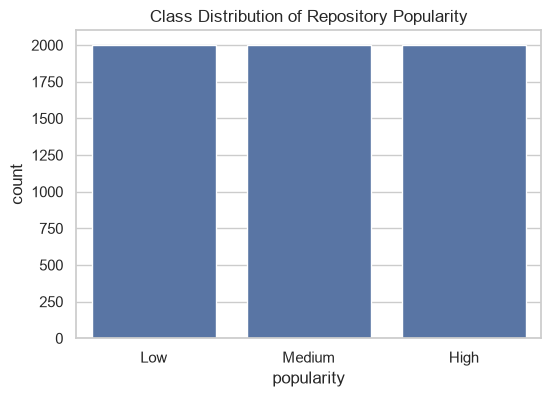

In [24]:
plt.figure(figsize=(6,4))
order = ["Low","Medium","High"]
sns.countplot(data=clean, x="popularity", order=order)
plt.title("Class Distribution of Repository Popularity")
plt.savefig("../screenshots/01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

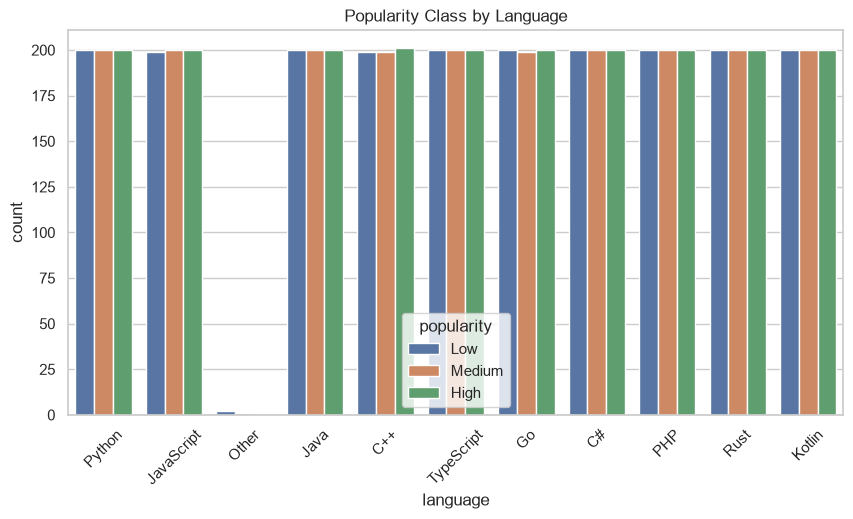

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(data=clean, x="language", hue="popularity", hue_order=order)
plt.xticks(rotation=45)
plt.title("Popularity Class by Language")
plt.savefig("../screenshots/02_class_by_language.png", dpi=150, bbox_inches="tight")
plt.show()

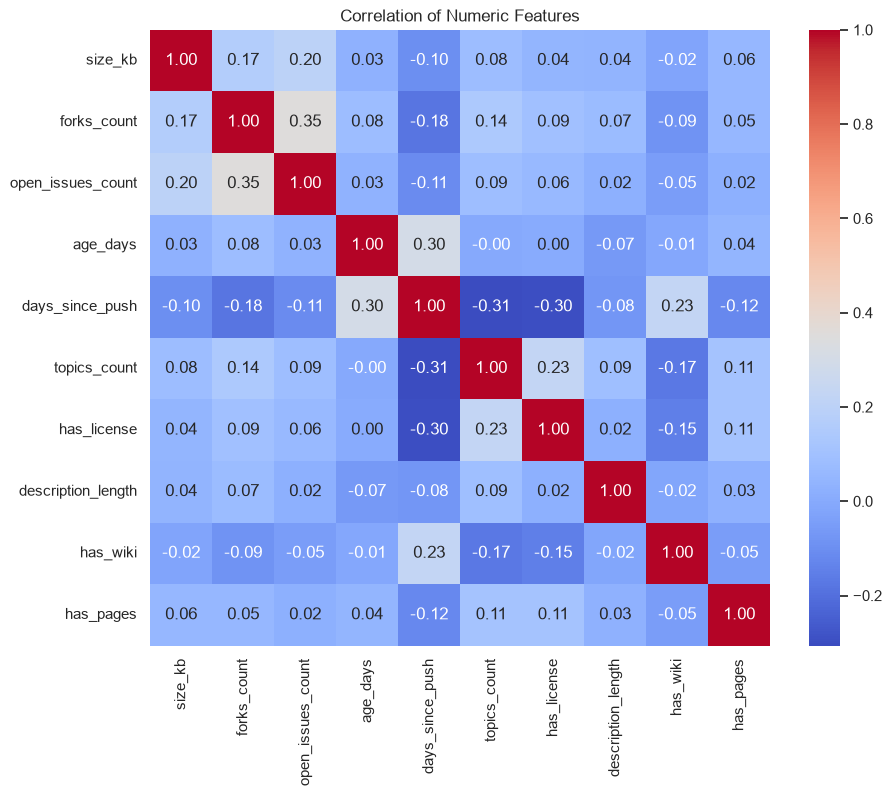

In [26]:
num_cols = ["size_kb","forks_count","open_issues_count","age_days",
            "days_since_push","topics_count","has_license",
            "description_length","has_wiki","has_pages"]
plt.figure(figsize=(10,8))
sns.heatmap(clean[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation of Numeric Features")
plt.savefig("../screenshots/03_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

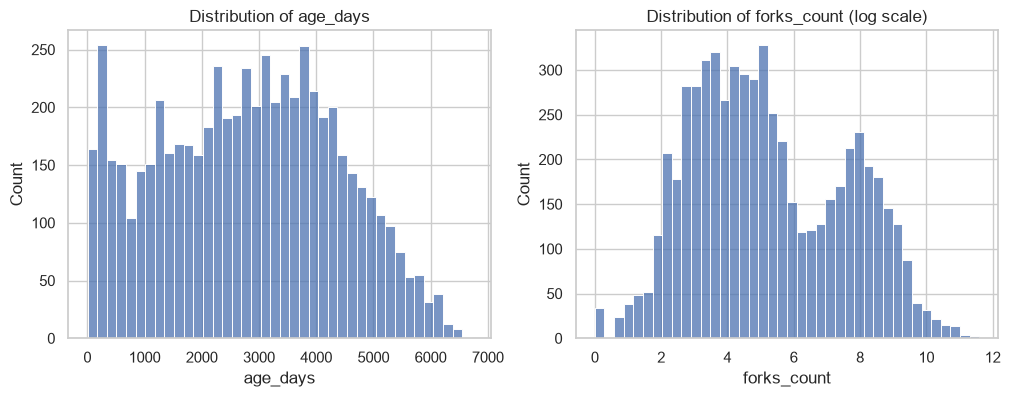

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(clean["age_days"], bins=40, ax=ax[0])
ax[0].set_title("Distribution of age_days")
sns.histplot(np.log1p(clean["forks_count"]), bins=40, ax=ax[1])
ax[1].set_title("Distribution of forks_count (log scale)")
plt.savefig("../screenshots/04_age_forks_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

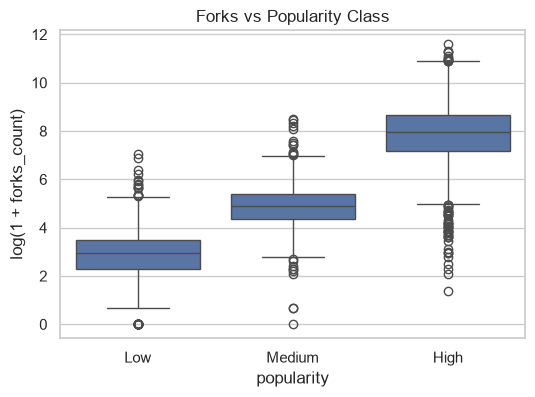

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(data=clean, x="popularity", y=np.log1p(clean["forks_count"]), order=order)
plt.ylabel("log(1 + forks_count)")
plt.title("Forks vs Popularity Class")
plt.savefig("../screenshots/05_forks_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
clean.to_csv("../data/clean_repos.csv", index=False)
print(pd.read_csv("../data/clean_repos.csv").shape)

(6000, 13)


In [30]:
# 1. Class distribution
print(clean["popularity"].value_counts(), "\n")

# 2. Language vs class (share of High within each language)
lang_tab = pd.crosstab(clean["language"], clean["popularity"], normalize="index").round(2)
print(lang_tab.sort_values("High", ascending=False), "\n")

# 3. Correlations (strongest pairs, ignoring the diagonal)
corr = clean[num_cols].corr()
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print(pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(6), "\n")

# 4. Medians by class (shows what separates Low / Medium / High)
print(clean.groupby("popularity")[["forks_count","age_days","days_since_push",
      "topics_count","description_length","open_issues_count","size_kb"]].median().loc[["Low","Medium","High"]], "\n")

# 5. Share with license / wiki / pages by class
print(clean.groupby("popularity")[["has_license","has_wiki","has_pages"]].mean().round(2).loc[["Low","Medium","High"]], "\n")

# 6. Skewness
print("skew age_days:", round(clean["age_days"].skew(), 2))
print("skew forks_count:", round(clean["forks_count"].skew(), 2))

popularity
High      2001
Low       2000
Medium    1999
Name: count, dtype: int64 

popularity  High   Low  Medium
language                      
C++         0.34  0.33    0.33
C#          0.33  0.33    0.33
Go          0.33  0.33    0.33
Java        0.33  0.33    0.33
JavaScript  0.33  0.33    0.33
Kotlin      0.33  0.33    0.33
PHP         0.33  0.33    0.33
Rust        0.33  0.33    0.33
Python      0.33  0.33    0.33
TypeScript  0.33  0.33    0.33
Other       0.00  0.67    0.33 

forks_count      open_issues_count    0.353736
days_since_push  topics_count        -0.306711
                 has_license         -0.299107
age_days         days_since_push      0.299075
days_since_push  has_wiki             0.228945
topics_count     has_license          0.226620
dtype: float64 

            forks_count  age_days  days_since_push  topics_count  \
popularity                                                         
Low                18.0    2366.0            734.5           0.0   
Medium  

## Observations from EDA

1. **Class distribution.** The dataset is balanced, with about 2,000 repositories
   in each class (High 2001, Low 2000, Medium 1999). This comes from the
   sampling design (equal queries per star range), not from GitHub's natural
   distribution, so random guessing would be right about 33% of the time.

2. **Forks and issues rise steeply with popularity.** Median forks_count is 18
   for Low, 131 for Medium and 2,840 for High, and median open issues goes
   from 3 to 17 to 186. These are the clearest separators between the classes.
   forks_count is extremely right-skewed (skew = 7.59), so a log scale was used
   for plotting, whereas age_days is almost symmetric (skew = 0.03).

3. **Popular repositories are actively maintained.** The median High repository
   was pushed 3 days ago, compared with 263 days for Medium and 734 days for
   Low. High repositories are also older (median 3,327 days vs 2,366 for Low),
   which suggests popularity builds up over time but only for projects that
   keep being updated.

4. **Documentation and metadata signals.** The share of repositories with a
   license rises from 74% (Low) to 88% (Medium) to 96% (High), and the share
   with GitHub Pages rises from 12% to 20% to 28%. Median size_kb also grows
   from about 1.5 MB to 5.4 MB to 57 MB, so larger projects tend to be more
   popular. Surprisingly, has_wiki goes the other way, falling from 78% (Low) to
   53% (High), possibly because well-known projects use external documentation
   sites instead of the GitHub wiki.

5. **Correlations are weak in pairs.** The strongest correlation is
   forks_count with open_issues_count (r = 0.35), and all other pairs are below
   0.31 in absolute value, so there is no problem with redundant features. Pearson
   correlation understates the forks signal because of its heavy skew, which is
   why the class-wise medians are more informative.

6. **Limitation: language chart is uninformative.** Each language contributes
   an equal share to each class (about 33%) because of the equal-quota
   collection, so this dataset cannot show whether a language makes a repository
   more popular. Language is still kept as a feature for the models.

## Day 3 start: load clean data

In [31]:
import pandas as pd, numpy as np
df = pd.read_csv("../data/clean_repos.csv")
print(df.shape, df["popularity"].value_counts())
print(df.isna().sum().sum())   # should be 0


(6000, 13) popularity
High      2001
Low       2000
Medium    1999
Name: count, dtype: int64
0


In [34]:
cat_cols  = ["language"]
skew_cols = ["size_kb", "forks_count", "open_issues_count"]
other_num = ["age_days", "days_since_push", "topics_count",
             "has_license", "description_length", "has_wiki", "has_pages"]

X = df[cat_cols + skew_cols + other_num]
y = df["popularity"]

In [33]:
print(df.columns.tolist())

['full_name', 'language', 'size_kb', 'forks_count', 'open_issues_count', 'age_days', 'days_since_push', 'topics_count', 'has_license', 'description_length', 'has_wiki', 'has_pages', 'popularity']


In [35]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

log_t = FunctionTransformer(np.log1p, feature_names_out="one-to-one")

# For Random Forest and XGBoost (no scaling)
prep_tree = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("log", log_t, skew_cols),
], remainder="passthrough")

# For Logistic Regression (log1p, then scale)
prep_lr = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("log", Pipeline([("log", log_t), ("sc", StandardScaler())]), skew_cols),
    ("num", StandardScaler(), other_num),
])

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
  "Logistic Regression": Pipeline([("prep", prep_lr),
        ("clf", LogisticRegression(max_iter=1000))]),
  "Random Forest": Pipeline([("prep", prep_tree),
        ("clf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))]),
  "XGBoost": Pipeline([("prep", prep_tree),
        ("clf", XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                              eval_metric="mlogloss", random_state=42, n_jobs=-1))]),
}

In [39]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="accuracy")
    rows.append({"Model": name, "CV Mean Acc": scores.mean(), "CV Std": scores.std()})
    print(name, scores.round(3))

results = pd.DataFrame(rows).sort_values("CV Mean Acc", ascending=False)
print(results.to_string(index=False))

Logistic Regression [0.904 0.902 0.915 0.912 0.922]
Random Forest [0.911 0.896 0.914 0.912 0.919]
XGBoost [0.906 0.9   0.909 0.919 0.926]
              Model  CV Mean Acc   CV Std
            XGBoost     0.912083 0.009237
Logistic Regression     0.911042 0.007205
      Random Forest     0.910417 0.007711


In [40]:
trained = {name: pipe.fit(X_train, y_train) for name, pipe in models.items()}

In [41]:
results = pd.DataFrame(rows).sort_values("CV Mean Acc", ascending=False)
results["CV Mean Acc"] = results["CV Mean Acc"].round(4)
results["CV Std"] = results["CV Std"].round(4)
results.reset_index(drop=True, inplace=True)
results

,Model,CV Mean Acc,CV Std
0,XGBoost,0.9121,0.0092
1,Logistic Regression,0.9110,0.0072
2,Random Forest,0.9104,0.0077


In [42]:
import os
os.makedirs("../results", exist_ok=True)   # use "results" if your notebook is in the project root
results.to_csv("../results/cv_comparison.csv", index=False)

import joblib
joblib.dump({"trained": trained, "le": le, "X_test": X_test, "y_test": y_test},
            "../models/day3_artifacts.joblib")

['../models/day3_artifacts.joblib']

Your three models are essentially tied. Here are observations you can use in the report:

Best model: XGBoost had the highest 5-fold CV accuracy at 91.21%, followed by Logistic Regression at 91.10% and Random Forest at 91.04%.
Trees vs. baseline: The tree-based models did not clearly outperform the Logistic Regression baseline. The gap between best and worst is only about 0.17 percentage points. This suggests the relationship between the features and popularity is largely captured by a simple, mostly linear boundary once the skewed columns are log-transformed.
Stability: CV standard deviations were small (0.0072 to 0.0092) for all models, so the results are consistent across folds. The differences between the models are smaller than this fold-to-fold variation, so none of them can be called meaningfully better than the others on accuracy alone.
Next step: Day 4 evaluates all three on the held-out test set with precision, recall and macro F1, and picks the best model by macro F1 rather than accuracy.

Why the numbers look like this: the 91% accuracy is probably driven mostly by one strong feature, most likely forks_count, since forks and stars rise together. That explains why a simple Logistic Regression keeps up with the tree models. This is the reason the plan's Day 4 bonus (retraining without forks_count) is worth doing. If the scores drop a lot, you'll have a good discussion point for your report.
